In [1]:
"""
The evaluation API requires that you set up a server which will respond to inference requests.
We have already defined the server; you just need write the predict function.
When we evaluate your submission on the hidden test set the client defined in `default_gateway` will run in a different container
with direct access to the hidden test set and hand off the data timestep by timestep.

Your code will always have access to the published copies of the copmetition files.
"""

import os

import pandas as pd
import polars as pl

import kaggle_evaluation.default_inference_server


In [2]:
dir = '/kaggle/input/hull-tactical-market-prediction'
train = pl.read_csv(os.path.join(dir, 'train.csv'))
test = pl.read_csv(os.path.join(dir, 'test.csv'))

In [3]:
print(train.shape)
print(train.columns)
print(train.dtypes)

(8990, 98)
['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']
[Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, String, S

In [4]:
# import matplotlib.pyplot as plt
# for col in train.columns[10:13]:
#     plt.figure()
#     plt.hist(train.select(pl.col(col).drop_nulls()), bins=20)
#     plt.title(col)
#     plt.xlabel(col)
#     plt.ylabel('Frequency')

In [5]:
print(len(train))

8990


In [6]:
# for col in train.columns:
#     n_unique = train.select(pl.col(col)).n_unique()
#     print(col, n_unique)

In [7]:
train.null_count()

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,1784,1006,1006,1006,1006,1006,1006,1006,1006,1006,1006,1006,1616,1006,1006,1006,1006,6969,1006,1006,1006,1006,1006,1006,1006,1006,1006,…,1006,1006,1006,1006,1574,1638,1616,1006,1006,1006,1006,1006,3537,1006,5733,1006,1511,1006,1006,3009,1006,1006,6049,1006,1006,1511,1006,1006,1006,1512,1006,1511,1006,4539,0,0,0


In [8]:
train = train.with_columns([
    pl.col(c).cast(pl.Float64, strict=False) for c, dtype in zip(train.columns, train.dtypes) if dtype==pl.String
])
print(list(train.dtypes))


[Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Int64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64, Float64]


In [9]:
train.null_count()

date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,…,P13,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,1784,1006,1006,1006,1006,1006,1006,1006,1006,1006,1006,1006,1616,1006,1006,1006,1006,6969,1006,1006,1006,1006,1006,1006,1006,1006,1006,…,1006,1006,1006,1006,1574,1638,1616,1006,1006,1006,1006,1006,3537,1006,5733,1006,1511,1006,1006,3009,1006,1006,6049,1006,1006,1511,1006,1006,1006,1512,1006,1511,1006,4539,0,0,0


Text(0.5, 1.0, 'market_forward_excess_returns')

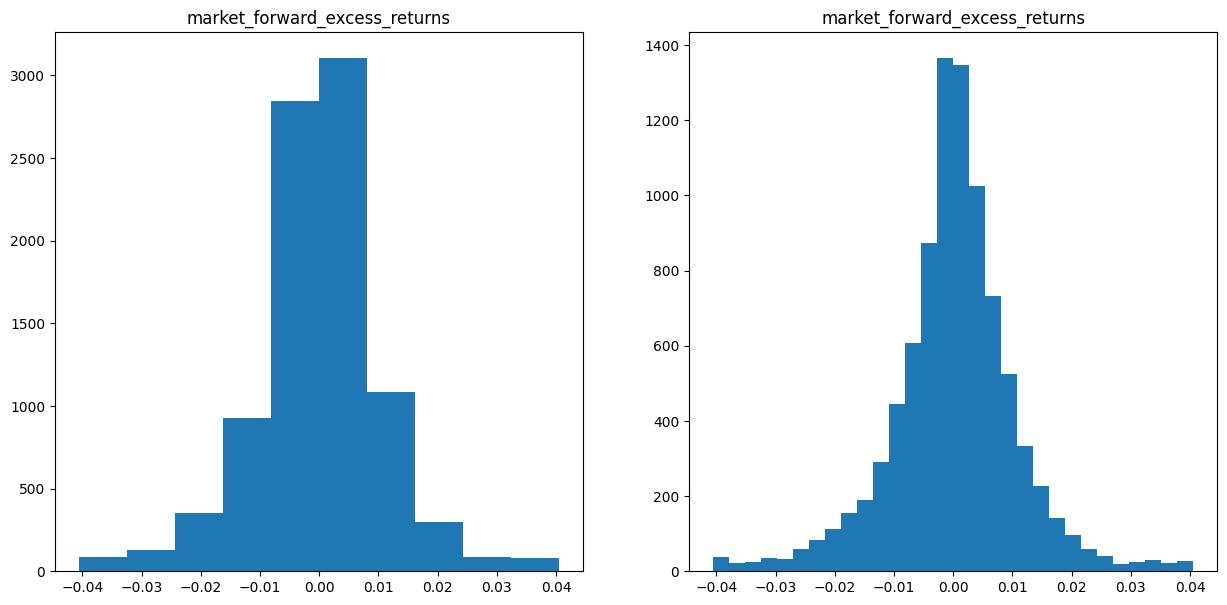

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(train['market_forward_excess_returns'], bins=10)
plt.set_title('market_forward_excess_returns')
# ax.xlabel('market_forward_excess_returns')
# ax.ylabel('Frequency')


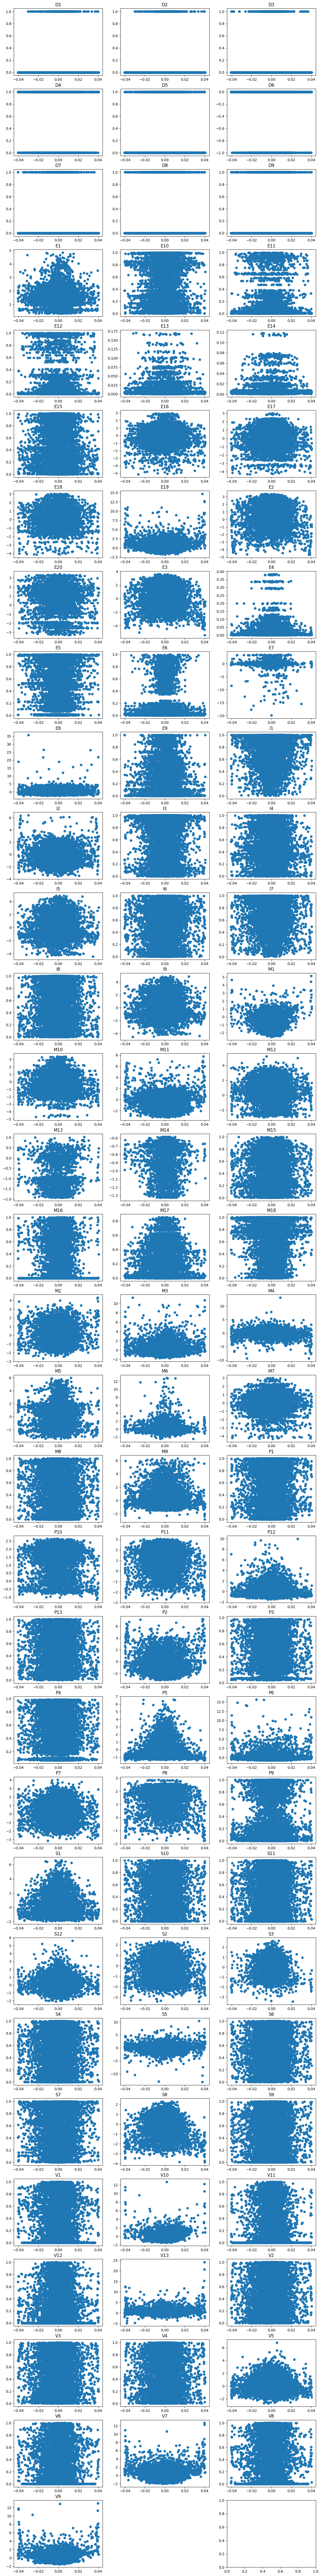

In [18]:
width = 3
height = (len(train.columns)-3+width-1)//width

fig, axes = plt.subplots(height, width, figsize=(15, 4*height))
axes = axes.flatten()

for i, col in enumerate(train.columns[1:-2]):
    ax = axes[i]
    xy = train['market_forward_excess_returns', col].drop_nulls()
    ax.scatter(xy[:, 0], xy[:, 1])
    ax.set_title(col)

for j in range(i, width*height):
    axes[j].set_visible(False)
    

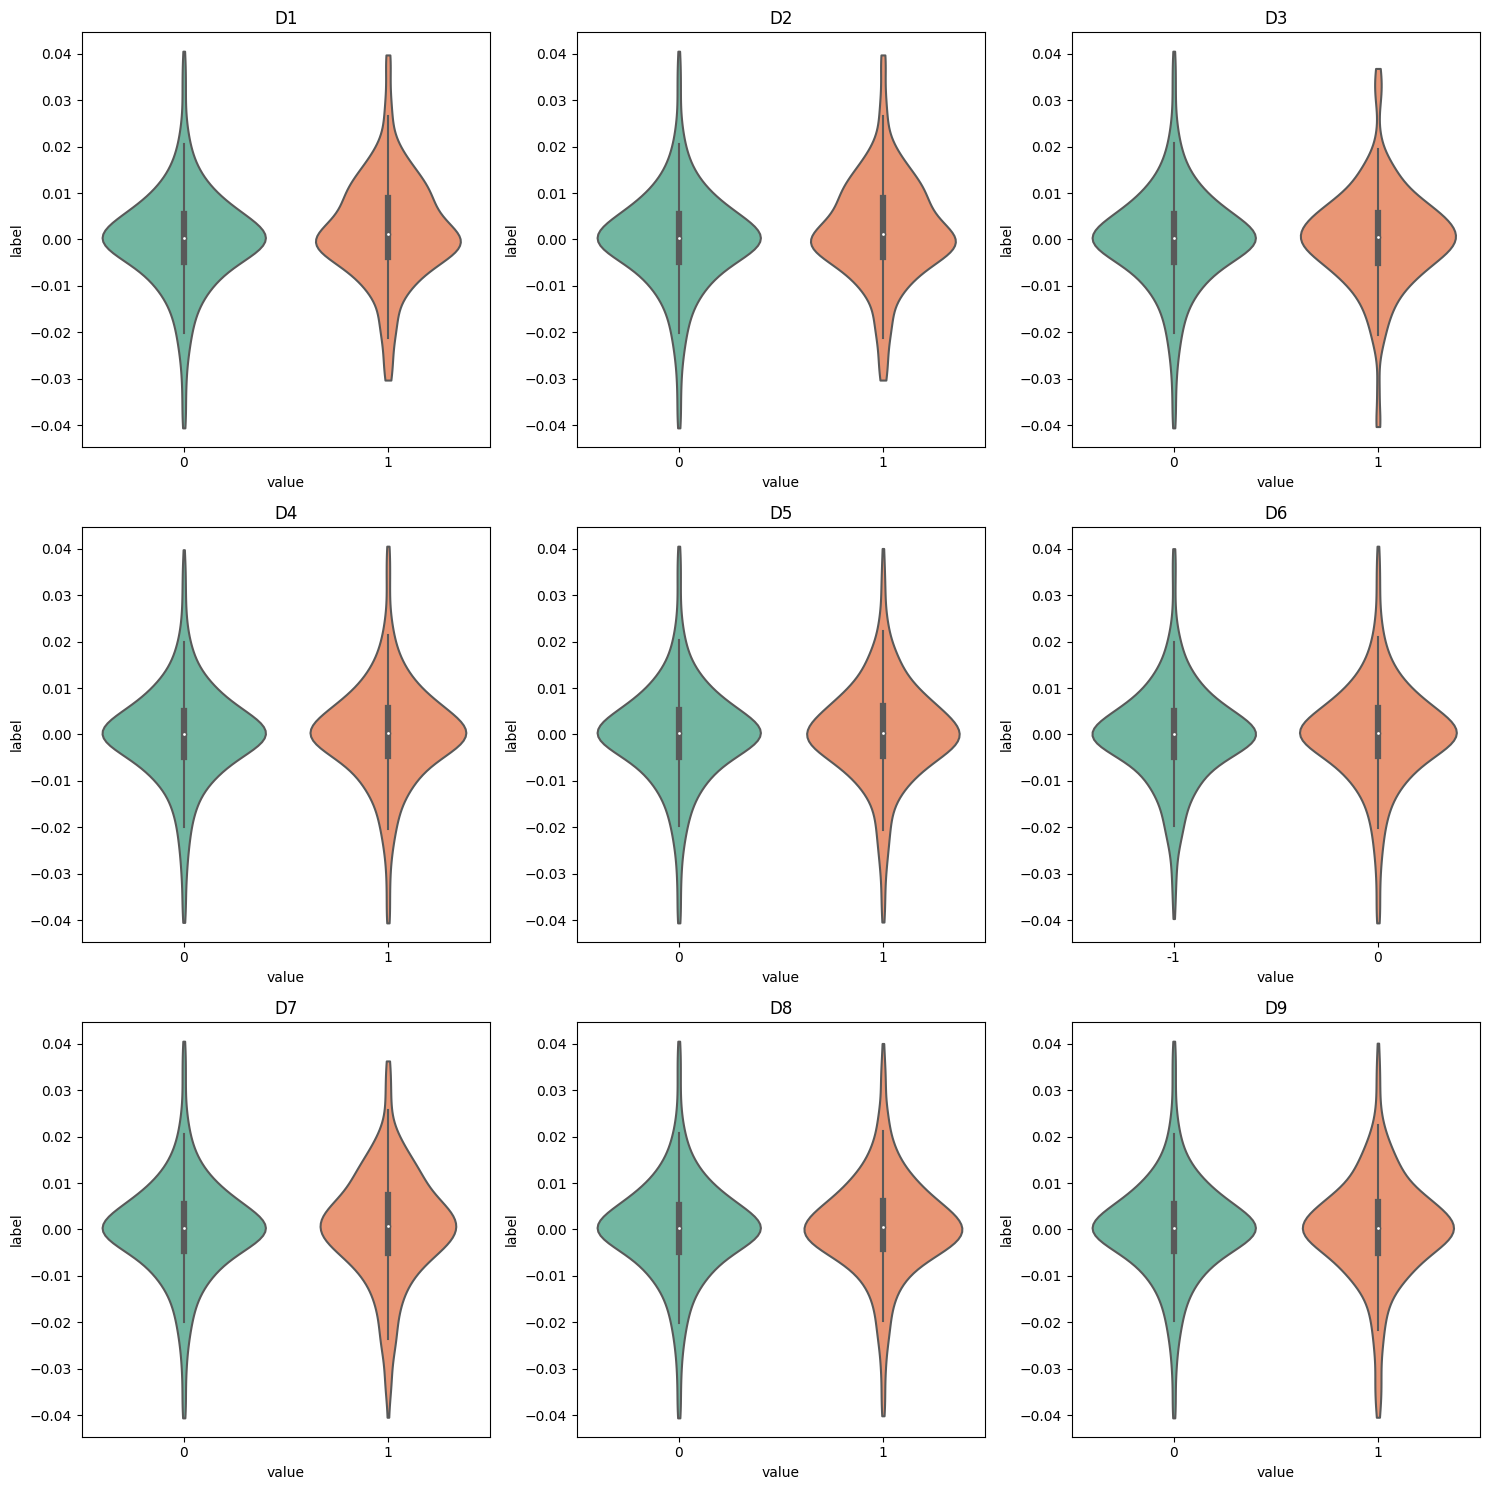

In [25]:
import math
import seaborn as sns
n_cols = 9
n_per_row = 3
n_rows = math.ceil(n_cols / n_per_row)

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(15, 5 * n_rows))
axes = axes.flatten()

# 各列ごとに描画
for i, col in enumerate(train.columns[1:10]):
    ax = axes[i]
    sns.violinplot(
        x=train[col].to_numpy(), y=train['market_forward_excess_returns'].to_numpy(),
        ax=ax,
        inner='box',        # 中央値と四分位範囲を表示
        cut=0,              # 外れ値部分を伸ばさない
        palette='Set2',     # カラーテーマ
        bw=0.3              # 平滑化の強さ（値が小さいほど細かい形になる）
    )
    ax.set_title(col)
    ax.set_ylabel("label")
    ax.set_xlabel("value")

plt.tight_layout()